In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_pickle('submission_data.pkl')
df = df.copy()
df['target'] = (df['Submission_Delay'] > 0).astype(int)
df = df.drop(columns=['Submission_Delay'])

df = df.select_dtypes(include=['number'])

scaler = StandardScaler()
features = df.columns.drop('target')
df[features] = scaler.fit_transform(df[features])

Matplotlib is building the font cache; this may take a moment.


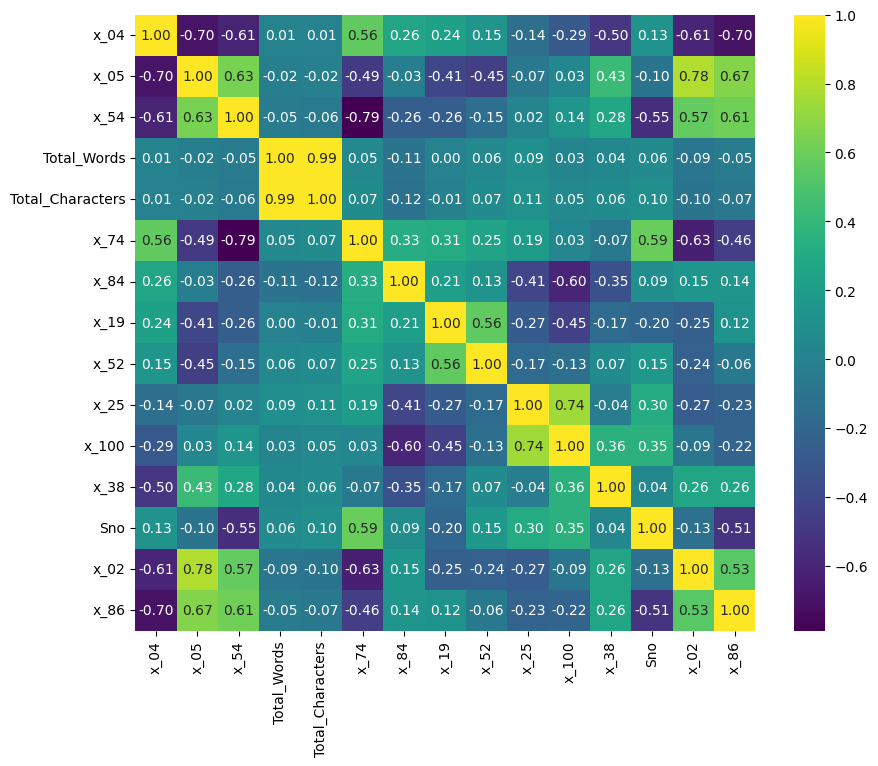

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

correlations = df.corr()['target'].abs().sort_values(ascending=False)
top_15_features = correlations.index[1:16]

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_15_features].corr(), annot=True, cmap='viridis', fmt=".2f")
plt.show()

d:\miniconda\envs\soc_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


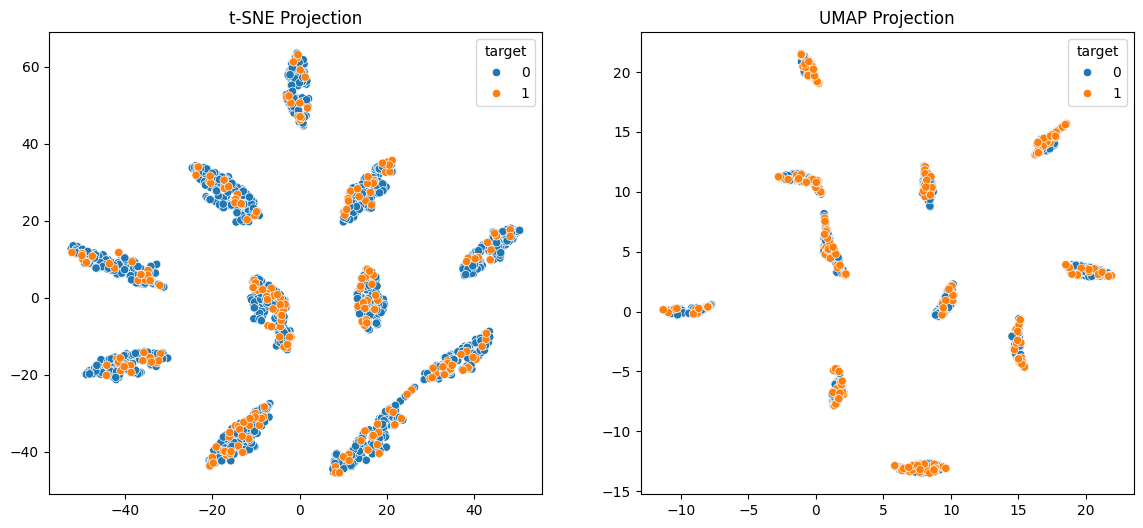

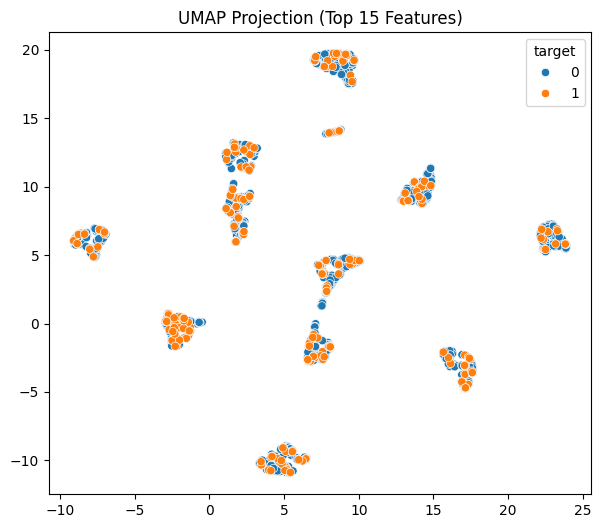

In [ ]:
from sklearn.manifold import TSNE
import umap

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(df[features])

reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(df[features])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['target'], ax=axes[0])
axes[0].set_title('t-SNE Projection')
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=df['target'], ax=axes[1])
axes[1].set_title('UMAP Projection')
plt.show()

# UMAP for Top 15 Features
X_umap_15 = reducer.fit_transform(df[top_15_features])

plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_umap_15[:, 0], y=X_umap_15[:, 1], hue=df['target'])
plt.title('UMAP Projection (Top 15 Features)')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# X = df[top_15_features]
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression()
svc = SVC()
rf = RandomForestClassifier(random_state=42)

log_reg.fit(X_train, y_train)
svc.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Logistic Regression:\n", classification_report(y_test, log_reg.predict(X_test)))
print("SVC:\n", classification_report(y_test, svc.predict(X_test)))
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93       284
           1       0.00      0.00      0.00        40

    accuracy                           0.88       324
   macro avg       0.44      0.50      0.47       324
weighted avg       0.77      0.88      0.82       324

SVC:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93       284
           1       0.00      0.00      0.00        40

    accuracy                           0.88       324
   macro avg       0.44      0.50      0.47       324
weighted avg       0.77      0.88      0.82       324

Random Forest:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       284
           1       0.40      0.10      0.16        40

    accuracy                           0.87       324
   macro avg       0.64      0.54      0.54       324
weighted avg       0.83      0

d:\miniconda\envs\soc_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\miniconda\envs\soc_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\miniconda\envs\soc_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\miniconda\envs\soc_env